In [139]:
import os
import configparser
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from drawarrow import ax_arrow
from matplotlib import colors
from pypalettes import load_cmap
from pyfonts import load_font
from matplotlib import font_manager
from matplotlib.gridspec import GridSpec
import matplotlib as mpl

## Get data

In [7]:
#set filepaths
project_root = os.path.abspath(os.getcwd())
root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
config_file =  os.path.join(root, 'config.cfg')

# geodata for shapefiles
config = configparser.ConfigParser()
config.read(config_file)
gdata_root = config['geodata']['path']

### Get London shapefiles

In [8]:
## Load london boroughs shapefile
london = gpd.read_file(os.path.join(gdata_root, 'london-shapefiles\\London_Borough_Excluding_MHW.shp'))
london = london.to_crs(4326)

# convert to CRS to have units in meters in the UK
_crs = "EPSG:32630"
london_reprojected = london.to_crs(_crs)

### Collect OSM data

Tutorial: https://williamthyer.github.io/posts/2021/4/bike_networks/

Updated code to align with OSMNX 2.0 release

In [3]:
import osmnx as ox

In [23]:
def get_cycleways_polygon(polygon): 
    
    # Configuring osmnx
    ox.settings.useful_tags_way.extend(["cycleway"])
        
    # Querying for roads and bike trails
    cycleways = ox.graph_from_polygon(polygon, network_type='bike', simplify=False)
    
    # Finding all non-cycleways in the network
    non_cycleways = [(u, v, k) for  u, v, k, d  in  
                     cycleways.edges(keys=True, data=True) 
                     if  not ('cycleway'  in  d  or  
                              d['highway']=='cycleway'
                              )]
   
    # Remove non-cycleways and isolated nodes
    cycleways.remove_edges_from(non_cycleways)
   
    return cycleways

In [24]:
osm_cycleways_df = []
osm_stats = {"NAME": [], "total_cycleways":[], "total_roads":[], "ratio": []}

#loop through all boroughs and append networks stats + cycleway geometries
for borough in london["NAME"].unique():
    polygon = london[london["NAME"]==borough]["geometry"].iloc[0]
    cycleways = get_cycleways_polygon(polygon)
    roads =  ox.graph_from_polygon(polygon, network_type='drive', simplify=True)
    cycleway_length = ox.basic_stats(cycleways)['edge_length_total']
    roads_length = ox.basic_stats(roads)['edge_length_total']
    osm_stats["total_cycleways"].append(cycleway_length)
    osm_stats["total_roads"].append(roads_length)
    rc_ratio = roads_length/cycleway_length
    osm_stats["NAME"].append(borough)
    osm_stats["ratio"].append(rc_ratio)

    #append cycleways geos
    cycleways_df_single = ox.convert.graph_to_gdfs(cycleways, nodes=False, edges=True)
    cols = ['highway',  'cycleway', 'length', 'geometry']
    cycleways_df_single = cycleways_df_single[cols].reset_index(drop=True)
    cycleways_df_single["NAME"] = borough
    osm_cycleways_df.append(cycleways_df_single)

In [ ]:
#save cycleways to csv file
osm_cycleways_all = pd.concat(osm_cycleways_df, ignore_index=True)
osm_cycleways_all = osm_cycleways_all.rename_geometry('WKT')
osm_cycleways_all.to_csv("osm_cycleways_by_borough.csv", index=False)

#save stats to csv file
osm_stats_df = pd.DataFrame(osm_stats)
osm_stats_df.to_csv("osm_road_cycleways_stats.csv", index=False)

#osm_stats_df

### Get prepared OSM data

Load prepared data sets so we don't have to rerun OSMnx code each time.

In [2]:
# load preprocessed csv file
osm_stats_df = pd.read_csv("osm_road_cycleways_stats.csv").rename(columns={"ratio":"road_cycleway_ratio"})
osm_cycleways_gdf = gpd.read_file("osm_cycleways_by_borough.csv")
osm_cycleways_gdf = osm_cycleways_gdf.set_crs('EPSG:4326')

### TfL cycle routes

In [3]:
# load TFL cycle routes
tfl_cycle_routes = gpd.GeoDataFrame.from_file('TfL_CycleRoutes.json')

#load summary stats for tfl cycle routes
tfl_cycle_routes_stats = pd.read_csv("tfl_cycle_routes_stats.csv")
tfl_cycle_routes_stats.head()

,NAME,Open,Planned,Total
0,Kingston upon Thames,15.1,1.6,16.7
1,Croydon,0.0,0.0,0.0
2,Bromley,0.0,2.4,2.4
3,Hounslow,7.9,5.3,13.2
4,Ealing,16.1,5.7,21.8


### Secure cycle storage

In [4]:
#load cycle hangar stats
hangar_stats = pd.read_csv("cycle_hangar_stats.csv")
hangar_stats.head()

,NAME,Total
0,Kingston upon Thames,77
1,Croydon,131
2,Bromley,37
3,Hounslow,29
4,Ealing,69


### Get cycling rates

In [136]:
#read in each tab and merge into one table
rates = pd.read_excel("cw0302-proportion-of-adults-that-cycle-by-frequency-purpose-and-local-authority.xlsx",
                       sheet_name="CW0302", skiprows=4)
#rates = rates[rates["ONS Code"].isin(london["GSS_CODE"])].reset_index(drop=True)
# replace missing data
years = ['2016', '2017', '2018','2019', '2020', '2021', '2022', '2023']
for year in years:
    rates[year] = rates[year].replace("[u]", np.nan)
rates.head()

,ONS Code,Area name,Class,Mode,Purpose,Frequency,2016,2017,2018,2019,2020,2021,2022,2023
0,E92000001,England,Country,Cycling,Any,At least once per month,17.1,16.9,16.1,16.1,16.1,13.1,13.1,14.7
1,E92000001,England,Country,Cycling,Any,At least once per week,11.9,11.9,11.5,11.2,11.6,9.1,9.3,10.1
2,E92000001,England,Country,Cycling,Any,At least 3 times per week,5.7,5.7,5.5,5.3,5.3,3.9,4.2,4.5
3,E92000001,England,Country,Cycling,Any,At least 5 times per week,3.4,3.4,3.3,3.2,3,2.1,2.3,2.5
4,E92000001,England,Country,Cycling,Leisure,At least once per month,13.9,13.6,13,13.1,13.4,9.9,9.2,11.9


### Borough household numbers

In [10]:
#read in each tab and merge into one table
households = pd.read_excel("roundedhouseholdestimates2023.xlsx",
                       sheet_name="2023", skiprows=6, 
                       usecols=[0,1,2],
                       names=["GSS_CODE", "NAME", "no_households"]
                         )

households.head()

,GSS_CODE,NAME,no_households
0,E06000047,County Durham,239900
1,E06000005,Darlington,47600
2,E06000001,Hartlepool,39700
3,E06000002,Middlesbrough,57900
4,E06000057,Northumberland,148400


### Get funding bids

Source: Data gathered by Sian Berry AM, Green Party Member of the London Assembly via Freedom of Information Request.

'Winning Better Borough Transport Plans'. Analysis of the latest borough bids and awards for local delivery plans 2023-25, February 2024

[Pdf download here](https://www.london.gov.uk/sites/default/files/2024-02/2024_02_SIAN_BERRY_WINNING_BETTER_BOROUGH_TRANSPORT_PLANS.pdf)

In [11]:
funding = pd.read_csv("transport_bids.csv",
                        skiprows=2, usecols=[0,2,3], 
                        header=None,
                        names=["GSS_CODE","transport_bid", "transport_funding"])
funding.head()

,GSS_CODE,transport_bid,transport_funding
0,E09000002,555.0,230.0
1,E09000003,809.0,80.0
2,E09000004,100.0,30.0
3,E09000005,0.0,0.0
4,E09000006,21.0,5.0


## Process data

In [12]:
#start with London borough shapefile
gdf = london[['NAME', 'GSS_CODE', 'HECTARES', 'NONLD_AREA', 'ONS_INNER', 'geometry']]

#add # of households
gdf = pd.merge(gdf, households[["GSS_CODE", "no_households"]], left_on="GSS_CODE", right_on="GSS_CODE", how="left")

#add funding
gdf = pd.merge(gdf, funding[["GSS_CODE", "transport_bid", "transport_funding"]], left_on="GSS_CODE", right_on="GSS_CODE", how="left")
gdf["funding_perk_household"] = gdf["transport_funding"] / gdf["no_households"]*1000

#add osm stats
gdf = pd.merge(gdf, osm_stats_df.rename(columns=lambda x: f"osm_{x}" if x != 'NAME' else x), 
               left_on="NAME", right_on="NAME", how="left",)
gdf["osm_cycle_road_ratio"] = gdf["osm_total_cycleways"] / gdf["osm_total_roads"] *100

#add tfl stats
gdf = pd.merge(gdf, tfl_cycle_routes_stats.rename(columns=lambda x: f"tfl_{x.lower()}" if x != 'NAME' else x), 
               left_on="NAME", right_on="NAME", how="left",)
gdf["tfl_cycle_road_ratio"] =  (gdf["tfl_open"]*1000) / (gdf["osm_total_roads"]) *100

#add hangar stats
gdf = pd.merge(gdf, hangar_stats.rename(columns=lambda x: f"hangar_{x.lower()}" if x != 'NAME' else x), 
               left_on="NAME", right_on="NAME", how="left",)
gdf["hangar_perk_household"] = gdf["hangar_total"] / gdf["no_households"]*1000

gdf.head()

,NAME,GSS_CODE,HECTARES,NONLD_AREA,ONS_INNER,geometry,no_households,transport_bid,transport_funding,funding_perk_household,osm_total_cycleways,osm_total_roads,osm_road_cycleway_ratio,osm_cycle_road_ratio,tfl_open,tfl_planned,tfl_total,tfl_cycle_road_ratio,hangar_total,hangar_perk_household
0,Kingston upon Thames,E09000021,3726.117,0.000,F,"POLYGON ((-0.33066 51.32901, -0.33057 51.32909...",72600,0.0,0.0,0.000000,67121.677362,6.469725e+05,9.638801,10.374735,15.1,1.6,16.7,2.333948,77,1.060606
1,Croydon,E09000008,8649.441,0.000,F,"POLYGON ((-0.06399 51.31864, -0.06405 51.31861...",166000,0.0,80.0,0.481928,68759.292136,1.519725e+06,22.102102,4.524456,0.0,0.0,0.0,0.000000,131,0.789157
2,Bromley,E09000006,15013.487,0.000,F,"POLYGON ((0.01216 51.29960, 0.01199 51.29979, ...",148700,21.0,5.0,0.033625,80419.021249,1.780396e+06,22.138995,4.516917,0.0,2.4,2.4,0.000000,37,0.248823
3,Hounslow,E09000018,5658.541,60.755,F,"POLYGON ((-0.24454 51.48870, -0.24466 51.48868...",98800,804.0,225.0,2.277328,134713.756341,9.509014e+05,7.058681,14.166953,7.9,5.3,13.2,0.830791,29,0.293522
4,Ealing,E09000009,5554.428,0.000,F,"POLYGON ((-0.41181 51.53408, -0.41186 51.53413...",138300,540.0,115.0,0.831526,166123.817524,1.100103e+06,6.622187,15.100752,16.1,5.7,21.8,1.463499,69,0.498915


In [236]:
#nice borough names
gdf["nicename"] = gdf["NAME"]

nicenames = {
    'Kingston upon Thames': "Kingston", 
    'Richmond upon Thames': "Richmond",
    'Hammersmith and Fulham': "Hammersmith",
    'Kensington and Chelsea': "Kensington", 
    'Barking and Dagenham': "Barking", 
    'City of London': "City"
}

for key, value in nicenames.items():
    gdf["nicename"] = gdf["nicename"].str.replace(key, value)

In [28]:
#save output file
gdf.to_csv("gdf_for_analysis.csv", index=False)

#save df output file
df = pd.DataFrame(gdf.drop(columns="geometry"))
df.to_csv("df_for_analysis.csv", index=False)

## Data viz

In [17]:
def filter_rates(purpose, frequency, year):
    filter = (rates["Purpose"] == purpose) & (rates["Frequency"]== frequency)
    rates_f = rates[filter][["ONS Code", year]]
    return rates_f

### More cycle lanes = more cyclists?

What makes people cycle regularly?

In [454]:
#data inputs
year = "2023"
rates_f = filter_rates("Any", "At least once per week", year)
data = pd.merge(df, rates_f, left_on="GSS_CODE", right_on="ONS Code", how="left")

#fonts
font_r = load_font(
  "https://github.com/googlefonts/opensans/blob/main/fonts/ttf/OpenSans-Regular.ttf?raw=true"
)
font_sm = load_font(
  "https://github.com/googlefonts/opensans/blob/main/fonts/ttf/OpenSans-Bold.ttf?raw=true"
)

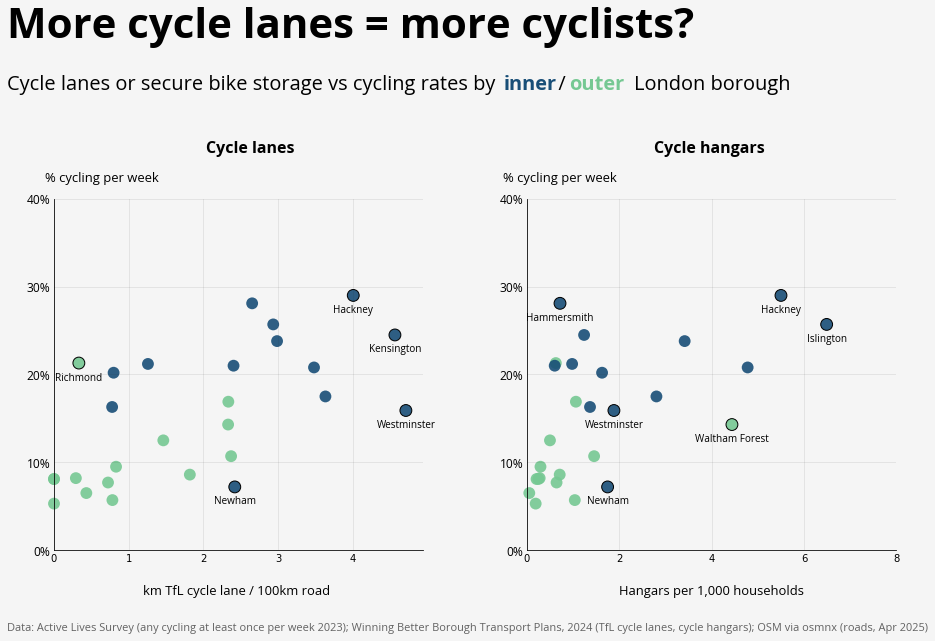

In [455]:
colors = {"bg": "#F5F5F5", "inner":"#184e77", "outer":"#76c893" }

#setup-------------------------------
fig, axes = plt.subplots(1,2, figsize=(13,8))
plt.subplots_adjust(hspace=0.2, wspace=0.28, left=0.05, top=0.75, bottom=0.14, right=0.95)
fig.set_facecolor(colors["bg"])

#plot data ---------------------------------
sns.scatterplot(data=data, x="tfl_cycle_road_ratio", y=year, hue="ONS_INNER",palette=[colors["outer"], colors["inner"]],
                s=140, ax=axes[0], alpha=0.9, linewidth=0, edgecolor="black", legend=False, clip_on=False)
sns.scatterplot(data=data, x="hangar_perk_household", y=year, hue="ONS_INNER", ax=axes[1],clip_on=False,
                palette=[colors["outer"], colors["inner"]],s=140, alpha=0.9, linewidth=0, edgecolor="black", legend=False)

#format axes ---------------------------------
for ax in axes:
    ax.set_ylim(ymin=0)
    ax.set_xlim(xmin=0)
    ax.set_facecolor(colors["bg"])
    for pos in ["top", "right"]:
        ax.spines[pos].set_visible(False)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_yticks([0,10,20,30,40], ["{}%".format(i) for i in [0,10,20,30,40]], fontproperties=font_r,fontsize=12)
    ax.tick_params(axis='both', length = 0)
    ax.grid(visible=True, axis='both', zorder=1, color = "#222222", alpha=0.1)

#axes[0].set_xticks([0,5,10,15,20,25], fontproperties=font_r,fontsize=12)
axes[1].set_xticks([0,2, 4, 6, 8], fontproperties=font_r,fontsize=12)
axes[0].text(axes[0].get_xlim()[1]/2,-5, "km TfL cycle lane / 100km road ", ha="center",
             fontproperties=font_r,fontsize=13)
axes[1].text(axes[1].get_xlim()[1]/2,-5, "Hangars per 1,000 households", ha="center",
             fontproperties=font_r,fontsize=13)
plt.figtext(0.04,0.78,"% cycling per week" ,ha="left",fontproperties=font_r,fontsize=13)
plt.figtext(0.53,0.78,"% cycling per week" ,ha="left",fontproperties=font_r,fontsize=13)

#grid titles
plt.figtext(0.04+0.22,0.83,"Cycle lanes", ha="center",fontproperties=font_sm, fontsize=16)
plt.figtext(0.53+0.22,0.83,"Cycle hangars", ha="center",fontproperties=font_sm, fontsize=16)

#annotations
for i, borough in enumerate(data["nicename"]): 
    if borough in ["Richmond", "Newham", "Westminster", "Hackney", "Kensington"]: 
        sns.scatterplot(x=[data.loc[i]["tfl_cycle_road_ratio"]], y=[data.loc[i][year]], facecolors="none",
                  s=140, ax=axes[0], alpha=1, linewidth=1, edgecolor="black", legend=False, clip_on=False)
        axes[0].text(data.loc[i]["tfl_cycle_road_ratio"], data.loc[i][year] - 1,data.loc[i]["nicename"],
                     ha="center", va="top",  fontsize=10, fontproperties=font_r  )
for i, borough in enumerate(data["nicename"]): 
    if borough in ["Newham", "Westminster", "Hackney", "Waltham Forest", "Islington", "Hammersmith"]: 
        sns.scatterplot(x=[data.loc[i]["hangar_perk_household"]], y=[data.loc[i][year]], facecolors="none",
                  s=140, ax=axes[1], alpha=1, linewidth=1, edgecolor="black", legend=False, clip_on=False       
                )
        axes[1].text(data.loc[i]["hangar_perk_household"], data.loc[i][year] - 1,data.loc[i]["nicename"],
                     ha="center", va="top",  fontsize=10, fontproperties=font_r  )

#title and footer
plt.figtext(0.,1.03, "More cycle lanes = more cyclists?", fontproperties = font_sm, fontsize=42, ha="left")
plt.figtext(0,0.94, "Cycle lanes or secure bike storage vs cycling rates by            /             London borough", 
            fontproperties = font_r, fontsize=20, ha="left")
plt.figtext(0.53,0.94, "inner", color=colors["inner"],
            fontproperties = font_sm, fontsize=20, ha="left")
plt.figtext(0.6,0.94, "outer", color=colors["outer"],
            fontproperties = font_sm, fontsize=20, ha="left")
plt.figtext(0.0,0.0, "Data: Active Lives Survey (any cycling at least once per week 2023); Winning Better Borough Transport Plans, 2024 (TfL cycle lanes, cycle hangars); OSM via osmnx (roads, Apr 2025)", 
            fontsize=11,  
            ha="left", alpha=0.6, fontproperties=font_r,)

#save
plt.savefig('1_cycle-lanes-vs-rates-2023.png', bbox_inches='tight', pad_inches=1, dpi=120)

plt.show()

### Trends

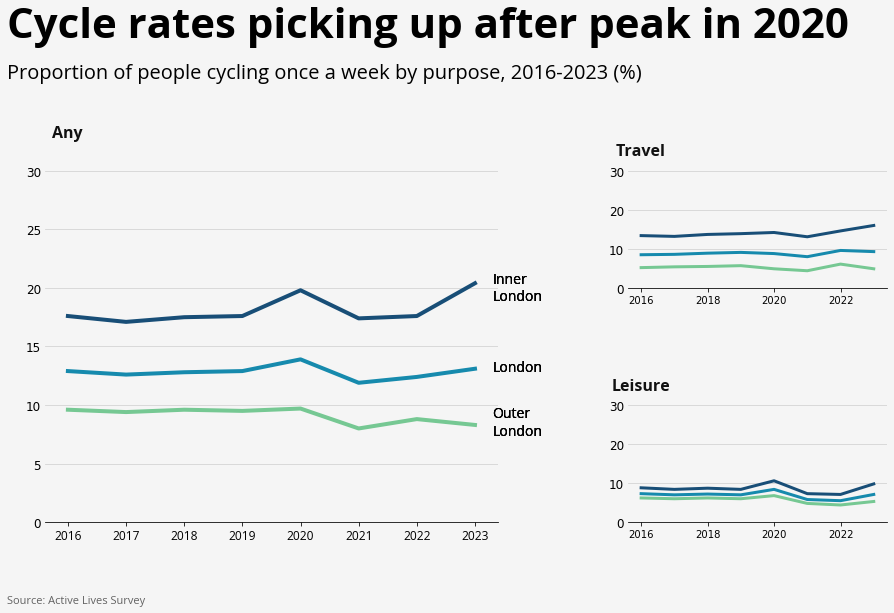

In [464]:
_filter = (rates["Area name"].isin(["London", "Inner London", "Outer London"])) & (rates["Frequency"]=="At least once per week")
pivot = rates[_filter].reset_index(drop=True)

clr = {"London": "#168aad" , "Inner London": "#184e77", "Outer London": "#76c893" }
lines = {"Any":4, "Travel": 3, "Leisure": 3}
circle = {"Any":0, "Travel": 0, "Leisure": 0}

# create objects
fig = plt.figure(figsize=(13,8))
gs = GridSpec(2, 5, figure=fig)
fig.set_facecolor("#F5F5F5")

# create sub plots as grid
ax1 = fig.add_subplot(gs[0:3, 0:3])
ax2 = fig.add_subplot(gs[0, 3:])
ax3 = fig.add_subplot(gs[1,3:])
axes = [ax1, ax2,ax3]

#adjust subplots
plt.subplots_adjust(hspace=1, wspace=2, left=0.05, top=0.75, bottom=0.14, right=0.95)

num = 0
for purpose in ["Any", "Travel", "Leisure"]:
    ax = axes[num]       
    data = pivot[pivot["Purpose"] == purpose]
    years = ['2016', '2017', '2018','2019', '2020', '2021', '2022', '2023']  
    
    for area in ["London", "Inner London", "Outer London"]:
        x = years
        y = data[data["Area name"]==area][years].iloc[0]
        ax.plot(x, y, color = clr[area], linewidth=lines[purpose], zorder=2, label=area)
        ax.scatter(x,y, s=circle[purpose], color=clr[area],  zorder=3)
    
    #xaxis
    ax.set_xlim(xmin=-0.4, xmax=7.4)
        
    #yaxis
    ax.set_ylim(ymin=0, ymax=30)
    ax.set_yticks(np.arange(0,31,5), fontproperties=font_r,fontsize=12)
    
    ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x)))
    ax.grid(visible=True, axis='y', zorder=1, color = "#D3D3D3")
    
    if num == 0:
        ax.tick_params(axis='y', length = 0, color = "#444444", labelsize=12)
        ax.set_yticks(np.arange(0,31,5), fontproperties=font_r,fontsize=12)
        ax.set_xticks(ax.get_xticks(), years,fontproperties=font_r,fontsize=12 )
    else:
        ax.tick_params(axis='y', length = 0, color = "#444444", labelsize=12)
        ax.set_xticks(np.arange(0,7,2),fontproperties=font_r,fontsize=12 )
        ax.set_yticks(np.arange(0,31,10), fontproperties=font_r,fontsize=12)

    #remove frame
    for pos in ["top", "left", "right"]:
        ax.spines[pos].set_visible(False)
    ax.set_title(purpose, x=0.05, y=1.08, fontsize=16, color="#111111", fontweight='bold',
                 fontproperties=font_sm)  
    ax.set_facecolor("#f5f5f5")
    num+=1
    
    #direct labels
    ax1.text(7.3 , 8.5, "Outer\nLondon", fontsize=14, va="center", fontproperties=font_r)
    ax1.text(7.3 , 13.2, "London",  fontsize=14, va="center", fontproperties=font_r)
    ax1.text(7.3 , 20, "Inner\nLondon",  fontsize=14, va="center", fontproperties=font_r)

#======
#Title, footer, notes
plt.figtext(0.01,1., "Cycle rates picking up after peak in 2020", 
            fontproperties=font_sm, va='center', fontsize=42)
plt.figtext(0.01,0.92, "Proportion of people cycling once a week by purpose, 2016-2023 (%)", 
            fontproperties=font_r, va='center', fontsize=20)
plt.figtext(0.01, 0, "Source: Active Lives Survey", 
            fontsize=11, ha="left", alpha=0.6, fontproperties=font_r)

#======
#save
plt.savefig("3-London-cycling-rates-trend_2016-2023.png",
            bbox_inches='tight',  transparent=False, pad_inches=1, dpi=120)

plt.show()

### Purpose

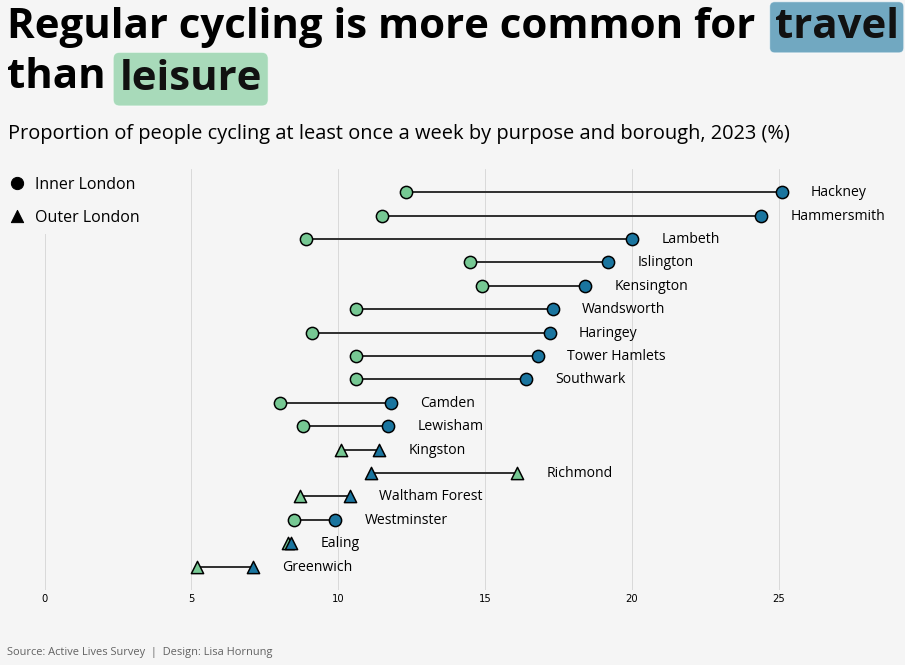

In [451]:
_filter = ((rates["Purpose"] != "Any")  & (rates["ONS Code"].isin(london["GSS_CODE"])) 
          &  (rates["Frequency"] == "At least once per week"))
pivot = rates[_filter].pivot(index=["ONS Code", "Area name"], columns="Purpose", 
                             values="2023").reset_index().dropna()
pivot = pd.merge(pivot, df[["GSS_CODE", "ONS_INNER", "nicename"]],left_on="ONS Code", 
                 right_on="GSS_CODE", how="left" )
pivot = pivot.sort_values(by="Travel", ascending=False).reset_index(drop=True).reset_index()
data = pivot.set_index("nicename")
colr = {"Travel": "#1a759f", "Leisure":"#76c893", "bg": "#f5f5f5"}
marker_dict = {"F": "^", "T": "o"}

###plot
fig, ax = plt.subplots(figsize=(13,9), sharey=True)
fig.set_facecolor(colr["bg"])
plt.subplots_adjust(hspace=1, wspace=2, left=0.05, top=0.75, bottom=0.1, right=0.9)

#dot plot
my_range = np.arange(len(data))
size = 150
plt.hlines(y=my_range, xmin=data['Leisure'], xmax=data['Travel'],linewidth=2,
            color='#333333', alpha=1, zorder=2)
for borough_type, marker in marker_dict.items():
    subset = data[data['ONS_INNER'] == borough_type]
    ax.scatter(subset['Leisure'], subset["index"], s=size, color=colr["Leisure"], 
            linewidth=1.5, edgecolors='black', marker=marker,
            alpha=1, label='Leisure', zorder=3)
    ax.scatter(subset['Travel'], subset["index"], s=size, color=colr["Travel"],
            linewidth=1.5, edgecolors='black', marker=marker,
            alpha=1 , label='Travel', zorder=3)

#add borough names
for i in range(len(data)):
    plt.text(max(data[["Travel", "Leisure"]].iloc[i])+ 1, my_range[i], 
            data.index[i], ha='left', va='center', fontsize=14, fontproperties=font_r ,
            )
    
#xaxis
ax.set_xlim(xmin=0, xmax=max(data[["Travel", "Leisure"]].max())+2)
plt.grid(visible=True, axis='x', zorder=1, color = "#D3D3D3",)
ax.set_xticks([0, 5,10,15,20,25], fontsize=24, )
        
#yaxis
ax.set_ylim(ymin=-1, ymax=len(data))
plt.tick_params(axis='both', length = 0, color = "#444444")
ax.set_yticks([])
ax.invert_yaxis()

#remove frame
for pos in ["top", "bottom", "left", "right"]:
    ax.spines[pos].set_visible(False)
ax.set_facecolor(colr["bg"])  
    
#legend --------------------------------
cbaxes = fig.add_axes([0.02, 0.65, 0.15, 0.1])
cbaxes.scatter(-1,0.55, marker="o", clip_on=False, s=size, color="black")
cbaxes.text(-0.6,0.5, "Inner London", ha="left", va="center", fontproperties=font_r, fontsize=16)
cbaxes.scatter(-1,-.45, marker="^", clip_on=False, s=size, color="black")
cbaxes.text(-0.6,-.5, "Outer London", ha="left", va="center", fontproperties=font_r, fontsize=16)
cbaxes.set_xlim(-1,2)
cbaxes.set_ylim(-1,1)
cbaxes.set_facecolor(colr["bg"])
for pos in ["top", "bottom", "left", "right"]:
    cbaxes.spines[pos].set_visible(False)
cbaxes.set_xticks([])
cbaxes.set_yticks([])
#cbaxes.axis("off")

#Title, footer, notes --------------------------------
plt.figtext(0.01,1.0, "Regular cycling is more common for          \nthan", fontproperties=font_sm, va='top', 
            fontsize=42, linespacing=1.3)
plt.figtext(0.83,1.0, "travel", color='#111111', fontproperties=font_sm, va='top', fontsize=42,
           bbox=dict(facecolor=colr["Travel"], edgecolor='white', boxstyle='round', pad=0.12, alpha=0.6))
plt.figtext(0.13,0.92, "leisure", fontproperties=font_sm, va='top', fontsize=42, color='#111111',
           bbox=dict(facecolor=colr["Leisure"], edgecolor='white', boxstyle='round', pad=0.15, alpha=0.6))
plt.figtext(0.0111,0.82, "Proportion of people cycling at least once a week by purpose and borough, 2023 (%)", 
            fontproperties=font_r, va='top', fontsize=20)
plt.figtext(0.01 , 0, "Source: Active Lives Survey  |  Design: Lisa Hornung", 
            fontsize=11, ha="left", alpha=0.6, fontproperties=font_r)

#save output
plt.savefig("4-london-cycling-rates-reason_2023.png", bbox_inches='tight', transparent=False,
             pad_inches=1, dpi=120)

plt.show()

### Tracking cycle lanes

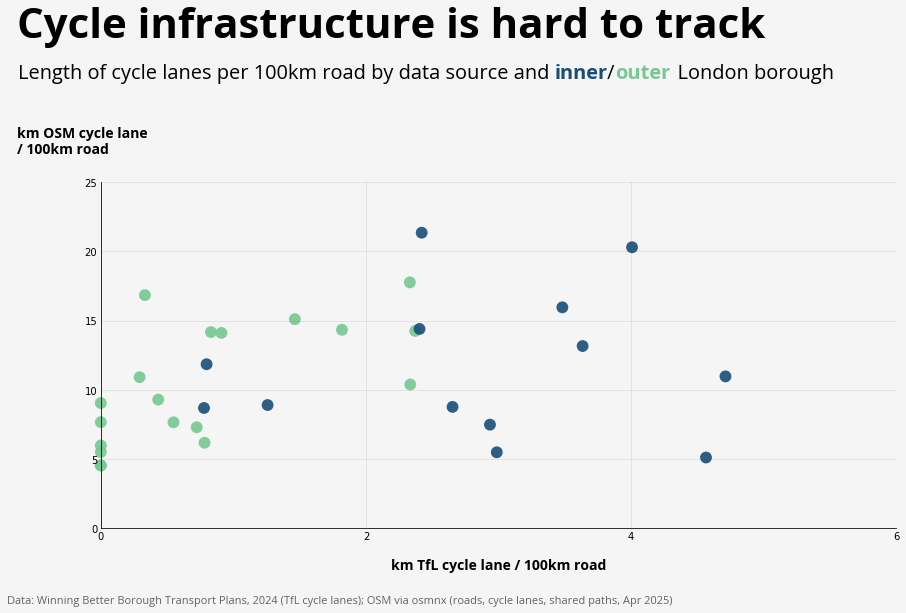

In [459]:
colors = {"bg": "#F5F5F5", "inner":"#184e77", "outer":"#76c893" }
data = df[df["nicename"]!="City"]

#setup-------------------------------
fig, ax = plt.subplots(figsize=(13,8))
plt.subplots_adjust(hspace=0, wspace=00, left=0.1, top=0.73, bottom=0.13, right=0.95)
fig.set_facecolor(colors["bg"])

#plot data ---------------------------------
sns.scatterplot(data=data, x="tfl_cycle_road_ratio", y="osm_cycle_road_ratio", hue="ONS_INNER",
                palette=[colors["outer"], colors["inner"]],
                s=140, ax=ax, alpha=0.9, linewidth=0, edgecolor="black", legend=False, clip_on=False)

#format axes ---------------------------------
ax.set_ylim(ymin=0)
ax.set_xlim(xmin=0)
ax.set_facecolor(colors["bg"])
for pos in ["top", "right"]:
    ax.spines[pos].set_visible(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticks(np.arange(0,27,5), fontproperties=font_r,fontsize=12)
ax.tick_params(axis='both', length = 0)
ax.grid(visible=True, axis='both', zorder=1, color = "#222222", alpha=0.1)
ax.set_xticks([0,2, 4, 6, ], fontproperties=font_r,fontsize=12)
ax.text(ax.get_xlim()[1]/2,-3, "km TfL cycle lane / 100km road", ha="center",
             fontproperties=font_sm,fontsize=14)
plt.figtext(0.01,0.78,"km OSM cycle lane\n/ 100km road", ha="left",fontproperties=font_sm,fontsize=14)


#Title, footer, notes --------------------------------
plt.figtext(0.01,1.0, "Cycle infrastructure is hard to track", fontproperties=font_sm, va='center', 
            fontsize=42, linespacing=1.3)
plt.figtext(0.0111,0.92, "Length of cycle lanes per 100km road by data source and           /            London borough", 
            fontproperties=font_r, va='center', fontsize=20)
plt.figtext(0.585,0.92, "inner", color=colors["inner"],
            fontproperties = font_sm, fontsize=20, ha="left", va='center',)
plt.figtext(0.65,0.92, "outer", color=colors["outer"],
            fontproperties = font_sm, fontsize=20, ha="left", va='center',)
plt.figtext(0.0,0.0, "Data: Winning Better Borough Transport Plans, 2024 (TfL cycle lanes); OSM via osmnx (roads, cycle lanes, shared paths, Apr 2025)", 
            fontsize=11,  
            ha="left", alpha=0.6, fontproperties=font_r,)

#save -------------------------------------
plt.savefig("2-cycle_infra_difference.png", bbox_inches='tight', transparent=False,
             pad_inches=1, dpi=120)


plt.show()

In [390]:
df.sort_values(by = "tfl_cycle_road_ratio")

,NAME,GSS_CODE,HECTARES,NONLD_AREA,ONS_INNER,no_households,transport_bid,transport_funding,funding_perk_household,osm_total_cycleways,osm_total_roads,osm_road_cycleway_ratio,osm_cycle_road_ratio,tfl_open,tfl_planned,tfl_total,tfl_cycle_road_ratio,hangar_total,hangar_perk_household,nicename
9,Barnet,E09000003,8674.837,0.000,F,163600,809.0,80.0,0.488998,89623.880978,1.502579e+06,16.765383,5.964672,0.0,1.4,1.4,0.000000,31,0.189487,Barnet
1,Croydon,E09000008,8649.441,0.000,F,166000,0.0,80.0,0.481928,68759.292136,1.519725e+06,22.102102,4.524456,0.0,0.0,0.0,0.000000,131,0.789157,Croydon
2,Bromley,E09000006,15013.487,0.000,F,148700,21.0,5.0,0.033625,80419.021249,1.780396e+06,22.138995,4.516917,0.0,2.4,2.4,0.000000,37,0.248823,Bromley
18,Sutton,E09000029,4384.698,0.000,F,91200,688.0,475.0,5.208333,63084.440132,8.245572e+05,13.070691,7.650705,0.0,0.0,0.0,0.000000,19,0.208333,Sutton
5,Havering,E09000016,11445.735,210.763,F,116800,200.0,50.0,0.428082,118723.423656,1.314794e+06,11.074424,9.029815,0.0,0.0,0.0,0.000000,17,0.145548,Havering
7,Harrow,E09000015,5046.330,0.000,F,112100,1050.0,235.0,2.096343,49378.982506,9.000853e+05,18.228106,5.486033,0.0,0.0,0.0,0.000000,0,0.000000,Harrow
20,Merton,E09000024,3762.466,0.000,F,79700,260.0,160.0,2.007528,78203.591781,7.173653e+05,9.173048,10.901502,2.1,2.0,4.1,0.292738,22,0.276035,Merton
19,Richmond upon Thames,E09000027,5876.111,135.443,F,81500,640.0,300.0,3.680982,136636.125062,8.113803e+05,5.938256,16.839961,2.7,4.2,6.9,0.332766,51,0.625767,Richmond
6,Hillingdon,E09000017,11570.063,0.000,F,117400,165.0,165.0,1.405451,137225.972453,1.478427e+06,10.773665,9.281892,6.4,0.0,6.4,0.432893,6,0.051107,Hillingdon
14,Bexley,E09000004,6428.649,370.619,F,107000,100.0,30.0,0.280374,82225.300751,1.076042e+06,13.086503,7.641461,5.9,0.0,5.9,0.548306,0,0.000000,Bexley


## Exploration

In [ ]:
def filter_rates(purpose, frequency):
    filter = (rates["Purpose"] == purpose) & (rates["Frequency"]== frequency)
    rates_f = rates[filter]
    return rates_f

rates_f = filter_rates("Any", "At least once per week")
rates_f.head()

,ONS Code,Area name,Class,Mode,Purpose,Frequency,2016,2017,2018,2019,2020,2021,2022,2023
1,E09000007,Camden,London Borough,Cycling,Any,At least once per week,13.9,15.3,14.5,15.9,15.6,17.5,16.5,17.5
13,E09000001,City of London,Inner London,Cycling,Any,At least once per week,21.7,14.6,NaN,13.4,15.7,13.2,NaN,NaN
25,E09000012,Hackney,London Borough,Cycling,Any,At least once per week,30.1,26.0,25.3,22.8,32.6,23.4,28.0,29.0
37,E09000013,Hammersmith and Fulham,London Borough,Cycling,Any,At least once per week,26.8,19.3,19.8,18.4,22.7,22.5,23.8,28.1
49,E09000014,Haringey,London Borough,Cycling,Any,At least once per week,13.8,15.1,11.2,15.0,14.2,12.1,12.0,20.2


<AxesSubplot:xlabel='osm_cycle_road_ratio', ylabel='2023'>

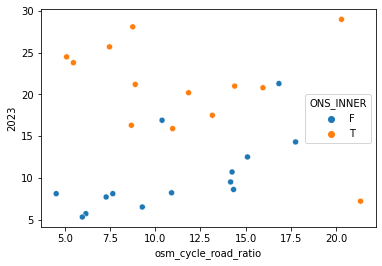

In [145]:
rates_f = filter_rates("Any", "At least once per week")
data = pd.merge(gdf, rates_f[["ONS Code", "2023"]], left_on="GSS_CODE", right_on="ONS Code", how="left")
sns.scatterplot(data=data, x="osm_cycle_road_ratio", y="2023", hue="ONS_INNER")

<AxesSubplot:xlabel='hangar_perk_household', ylabel='2023'>

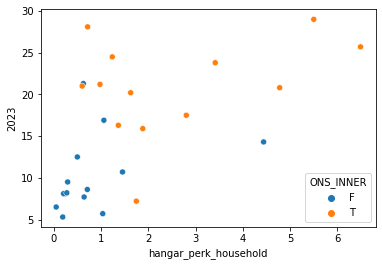

In [136]:
rates_f = filter_rates("Any", "At least once per week")
data = pd.merge(gdf, rates_f[["ONS Code", "2023"]], left_on="GSS_CODE", right_on="ONS Code", how="left")
sns.scatterplot(data=data, x="hangar_perk_household", y="2023", hue="ONS_INNER")

<AxesSubplot:xlabel='hangar_x_ratio', ylabel='2023'>

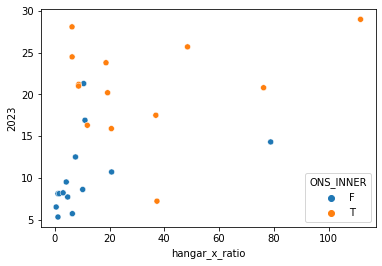

In [146]:
rates_f = filter_rates("Any", "At least once per week")
data = pd.merge(gdf, rates_f[["ONS Code", "2023"]], left_on="GSS_CODE", right_on="ONS Code", how="left")
data["hangar_x_ratio"] = data["hangar_perk_household"] * data["osm_cycle_road_ratio"]
sns.scatterplot(data=data, x="hangar_x_ratio", y="2023", hue="ONS_INNER")

<AxesSubplot:xlabel='tfl_cycle_road_ratio', ylabel='2023'>

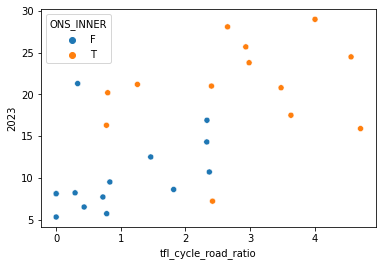

In [152]:
rates_f = filter_rates("Any", "At least once per week")
data = pd.merge(gdf, rates_f[["ONS Code", "2023"]], left_on="GSS_CODE", right_on="ONS Code", how="left")
sns.scatterplot(data=data, x="tfl_cycle_road_ratio", y="2023", hue="ONS_INNER")

## Playground

#### Map

In [219]:
pos_dict = {'E09000001': 29,  'E09000002': 32, 'E09000003': 12, 'E09000004': 40,  'E09000005': 19, 'E09000006': 46,
           'E09000007': 20, 'E09000008': 45,  'E09000009': 18,  'E09000010': 5,  'E09000011': 39,  'E09000012': 22,
           'E09000013': 26,  'E09000014': 13,  'E09000015': 11,  'E09000016': 24, 'E09000017': 17,  'E09000018': 25,
           'E09000019': 21,  'E09000020': 27,  'E09000021': 43, 'E09000022': 36,  'E09000023': 38,  'E09000024': 44,
           'E09000025': 31,  'E09000026': 23,  'E09000027': 34,  'E09000028': 37,  'E09000029': 52,  'E09000030': 30,
           'E09000031': 14,  'E09000032': 35,  'E09000033': 28}
pos_dict.keys()

dict_keys(['E09000001', 'E09000002', 'E09000003', 'E09000004', 'E09000005', 'E09000006', 'E09000007', 'E09000008', 'E09000009', 'E09000010', 'E09000011', 'E09000012', 'E09000013', 'E09000014', 'E09000015', 'E09000016', 'E09000017', 'E09000018', 'E09000019', 'E09000020', 'E09000021', 'E09000022', 'E09000023', 'E09000024', 'E09000025', 'E09000026', 'E09000027', 'E09000028', 'E09000029', 'E09000030', 'E09000031', 'E09000032', 'E09000033'])

In [ ]:
#map 

#dictionary of London boroughs and their ONS codes
pos_dict = {'E09000001': 29,  'E09000002': 32, 'E09000003': 12, 'E09000004': 40,  'E09000005': 19, 'E09000006': 46,
           'E09000007': 20, 'E09000008': 45,  'E09000009': 18,  'E09000010': 5,  'E09000011': 39,  'E09000012': 22,
           'E09000013': 26,  'E09000014': 13,  'E09000015': 11,  'E09000016': 24, 'E09000017': 17,  'E09000018': 25,
           'E09000019': 21,  'E09000020': 27,  'E09000021': 43, 'E09000022': 36,  'E09000023': 38,  'E09000024': 44,
           'E09000025': 31,  'E09000026': 23,  'E09000027': 34,  'E09000028': 37,  'E09000029': 52,  'E09000030': 30,
           'E09000031': 14,  'E09000032': 35,  'E09000033': 28}

display_dict = {'E09000007': 'CMD', 'E09000001': 'CTY', 'E09000012': 'HCK', 'E09000013': 'HMS', 'E09000014': 'HGY',
             'E09000019': 'ISL', 'E09000020': 'KNS', 'E09000022': 'LAM', 'E09000023': 'LSH', 'E09000025': 'NWM',
             'E09000028': 'SWR', 'E09000030': 'TOW', 'E09000032': 'WNS', 'E09000033': 'WST', 'E09000002': 'BAR',
             'E09000003': 'BRN', 'E09000004': 'BXL',  'E09000005': 'BRT',  'E09000006': 'BRM',  'E09000008': 'CRD',
             'E09000009': 'ELG',  'E09000010': 'ENF',  'E09000011': 'GRN',  'E09000015': 'HRW',  'E09000016': 'HVG',
             'E09000017': 'HDN',  'E09000018': 'HNS',  'E09000021': 'KNG',  'E09000024': 'MRT',  'E09000026': 'RDB',
             'E09000027': 'RCH',  'E09000029': 'STN',  'E09000031': 'WTH'}


In [ ]:
colors = {"bg": "#F5F5F5", "inner":"#22A2AA", "outer":"#003F92" }

#data inputs
purpose = "Any"
data = rates[(rates["Purpose"]==purpose) & (rates["Frequency"].isin(["At least once per week", "At least once per month"]))]
data = rates[(rates["Purpose"]==purpose) & (rates["Frequency"].isin(["At least once per week"]))]
data["Display name"] = data["ONS Code"].map(display_dict)
data
data["Display name"] = data["ONS Code"].map(display_dict)
#data["pos"] = data["ONS Code"].map(pos_dict)

#===== Plotting
#create layout and initialise figure
layout = [
            ["___","___","___","___","ENF","___","___","___"],
            ["___","___","HRW","BRN","HGY","WTH","___","___"],
            ["HDN","ELG","BRT","CMD","ISL","HCK","RDB","HVG"],
            ["HNS","HMS","KNS","WST","CTY","TOW","NWM","BAR"],
            ["___","RCH","WNS","LAM","SWR","LSH","GRN","BXL"],
            ["___","___","KNG","MRT","CRD","BRM","___","___"],
            ["___","___","___","STN","___","___","___","___"],
            ]

fig,axs = plt.subplot_mosaic(layout, figsize=(12,9), empty_sentinel="___") 
fig.set_facecolor(colors["bg"])
plt.subplots_adjust(wspace=0.1, hspace=0.1, left=0.05, right=0.95, bottom=0.05)

# plotting boroughs
y_values = ['2016', '2017', '2018','2019', '2020', '2021', '2022', '2023']        
x_values = [1,2,3,4,5,6,7,8]
height = max(data[y_values].max()) + 30

    ##loop through data
for ax in axs:
        data_filtered = data[data["Display name"]==ax]
            
        #display name of borough
        axs[ax].text(1.05, height-10, ax, fontsize=10, ha="left", va='top', color="#111111",
                fontproperties=font_r)
        
        #plot area chart
        axs[ax].fill_between(x_values, list(data_filtered[y_values].values[0]), zorder=1, color=colors["area"], alpha=0.7,linewidth=0)   
        axs[ax].plot(x_values, list(data_filtered[y_values].values[0]), zorder=2, color=colors["line"],linewidth=2.5)    
                
        #display most recent % value
        count=0
        for j in range(len(y_values)):
            if (count==0) and (math.isnan(data_filtered[reversed(y_values)].values[0][j])==False):
                    axs[ax].text(max(x_values)-0.05, height-7, '{:,.0f}%'.format(data_filtered[reversed(y_values)].values[0][j]), 
                    fontproperties=font_sm, ha="right", fontsize=20, fontweight='bold', va='top', color=colors["value"])
                    axs[ax].scatter(x_values[6-j], data_filtered[reversed(y_values)].values[0][j], zorder=3,color=colors["line"])
                    count+=1
            
        #format axis
        axs[ax].set_xlim(xmin=0.8, xmax=7.2)
        axs[ax].set_ylim(ymax=height, ymin=0) 
        axs[ax].set_facecolor(colors["bg"])    
        axs[ax].axis("off")
        
        
#============= Legend           
lgd = fig.add_axes([0.82, 0.05, 0.1, 0.1]) #axes to hold legend
lgd.text(1.05,height-3,data["Display name"][0], fontsize=8, ha="left", va='top', color="#111111",fontproperties=font_r)
lgd.fill_between(x_values,list(data.loc[0][y_values].values), zorder=1,color="#9EA7A9", alpha=0.7,linewidth=0)    
lgd.plot(x_values,list(data.loc[0][y_values].values), zorder=2,color="#333333",linewidth=1.5)    
lgd.scatter(max(x_values),list(data.loc[0][y_values].values)[-1], zorder=3,color="#333333")
lgd.text(max(x_values)-0.05, height-2, '{:,.0f}%'.format(list(data.loc[0][y_values].values)[-1]), 
            fontproperties=font_sm, ha="right", fontsize=15, fontweight='bold', va='top', color="#333333")
lgd.set_xlim(xmin=0.8, xmax=6.2) 
lgd.set_ylim(ymax=height, ymin=0) 
lgd.set_facecolor("#DBE2E3")
for pos in ["top", "bottom", "right", "left"]:
        lgd.spines[pos].set_visible(False)
lgd.set_xticks([1,7], ["2016", "2022"],fontsize = 10)
lgd.set_yticks([])
lgd.annotate('latest\nrate', xy=(max(x_values)+0.3, height-10), xycoords='data', xytext=(10, 0), textcoords='offset points', 
                    fontsize=11, fontproperties=font_r,ha='left', va='center', annotation_clip=False,
                        arrowprops=dict(arrowstyle="->",facecolor='black'))
lgd.annotate('borough', xy=(min(x_values)+0.2, height-1), xycoords='data', xytext=(0, 16), textcoords='offset points', 
                    fontsize=11, fontproperties=font_r,ha='center', va='center', annotation_clip=False,
                        arrowprops=dict(arrowstyle="->",facecolor='black'))


  

### Other


In [ ]:
city_name = 'Lewisham'
polygon = london[london["NAME"]==city_name]["geometry"].iloc[0]
cycleways = get_cycleways_polygon(polygon)
roads =  ox.graph_from_polygon(polygon, network_type='drive', simplify=True)

In [51]:
cycleways = get_cycleways_polygon(polygon)
roads =  ox.graph_from_polygon(polygon, network_type='drive', simplify=True)

In [49]:
#Bexley
cycleways_stats = ox.basic_stats(cycleways)
roads_stats = ox.basic_stats(roads)

cycleway_length = cycleways_stats['edge_length_total']
roads_length = roads_stats['edge_length_total']

rc_ratio = roads_length/cycleway_length
rc_ratio

13.921139808794827

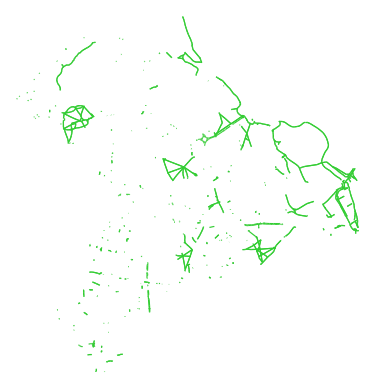

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [42]:
# Get cycleways network
# Plotting
fig, ax = plt.subplots()
ox.plot_graph(
	cycleways,
	ax=ax,
	node_size=0,
	edge_linewidth=.85,
	edge_color='limegreen')